# Średnie kroczące i inne operacje w oknach

In [1]:

import requests
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf  # Do świec (candlestick)
import pandas_ta as ta
import plotly.graph_objects as go
import plotly.io as pio



In [2]:
def get_binance_data(symbol="BTCUSDT", interval="5m", limit=50):
    url = f"https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
    response = requests.get(url)
    data = response.json()
    
    df = pd.DataFrame(data, columns=["timestamp", "open", "high", "low", "close", "volume", "_", "_", "_", "_", "_", "_"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")  # Konwersja na datę
    df[["open", "high", "low", "close"]] = df[["open", "high", "low", "close"]].astype(float)  # Zamiana na liczby
    return df

df = get_binance_data()


# mpf.plot(df.set_index("timestamp"), type="candle", style="charles", title="Bitcoin - świeczki", ylabel="Cena (USDT)")


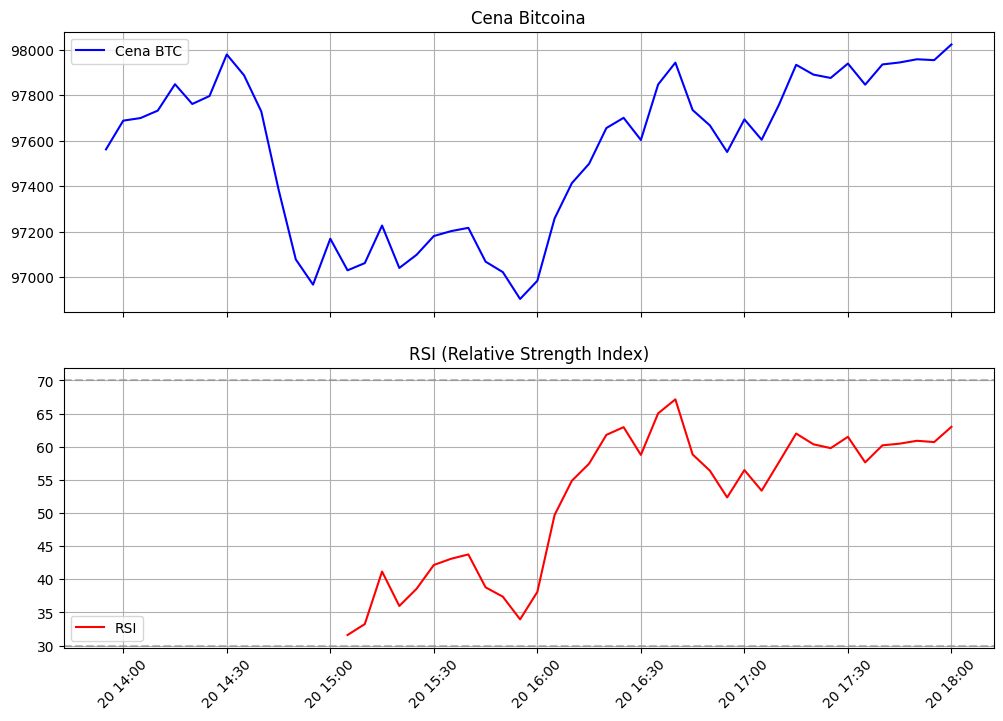

In [3]:
# Oblicz RSI
df["rsi"] = ta.rsi(df["close"], length=14)

# Tworzenie wykresu
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Wykres ceny
ax[0].plot(df["timestamp"], df["close"], label="Cena BTC", color="blue")
ax[0].set_title("Cena Bitcoina")
ax[0].legend()
ax[0].grid()

# Wykres RSI
ax[1].plot(df["timestamp"], df["rsi"], label="RSI", color="red")
ax[1].axhline(70, color="gray", linestyle="--", alpha=0.5)  # Poziom wykupienia
ax[1].axhline(30, color="gray", linestyle="--", alpha=0.5)  # Poziom wyprzedania
ax[1].set_title("RSI (Relative Strength Index)")
ax[1].legend()
ax[1].grid()

plt.xticks(rotation=45)  # Obrócenie dat dla lepszej widoczności
plt.show()

In [6]:
fig = go.Figure(data=[go.Candlestick(
    x=df["timestamp"],
    open=df["open"],
    high=df["high"],
    low=df["low"],
    close=df["close"],
)])
pio.renderers.default = "vscode"
fig.update_layout(title="Bitcoin Candlestick Chart", xaxis_title="Data", yaxis_title="Cena (USDT)")
fig.show()